In [17]:
import os
import sys

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import yaml
from chroma import structure, plotting
from OpenMiChroM.CndbTools import cndbTools
import seaborn as sns

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

plt.style.use("chroma.paper")

In [4]:
conditions = ["complete", "nucleolus", "lamina", "control"]

NUM_REPLICAS = 32
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

OUTPUT_FOLDER = "/scratch/mm146/Polarization/3_IMR-90_hg38_fields-nb/4_analysis/distances-distributions/data"

In [5]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [6]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [7]:
title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

In [36]:
# for testing the figures:
mpl.rcParams["figure.dpi"] = 300

# Concatenating files (only need to be done once)


In [5]:
distance_histograms = {}
for condition in conditions:
    distance_histograms[condition] = {}

    for replica in range(1, NUM_REPLICAS + 1):
        print(
            f"Processing condition: {condition}, replica: {replica}"
        )
        with h5py.File(
            os.path.join(
                OUTPUT_FOLDER,
                condition,
                f"distance-histograms-replica{replica}.h5",
            ),
            "r",
        ) as input_file:
            for key in input_file.keys():
                if key not in distance_histograms[condition]:
                    distance_histograms[condition][key] = input_file[
                        key
                    ][:]
                else:
                    if key not in ["xbins", "ybins"]:
                        distance_histograms[condition][
                            key
                        ] += input_file[key][:]

Processing condition: complete, replica: 1
Processing condition: complete, replica: 2
Processing condition: complete, replica: 3
Processing condition: complete, replica: 4
Processing condition: complete, replica: 5
Processing condition: complete, replica: 6
Processing condition: complete, replica: 7
Processing condition: complete, replica: 8
Processing condition: complete, replica: 9
Processing condition: complete, replica: 10
Processing condition: complete, replica: 11
Processing condition: complete, replica: 12
Processing condition: complete, replica: 13
Processing condition: complete, replica: 14
Processing condition: complete, replica: 15
Processing condition: complete, replica: 16
Processing condition: complete, replica: 17
Processing condition: complete, replica: 18
Processing condition: complete, replica: 19
Processing condition: complete, replica: 20
Processing condition: complete, replica: 21
Processing condition: complete, replica: 22
Processing condition: complete, replica: 

In [7]:
# convert to probability density distributions
for condition in conditions:
    for key in distance_histograms[condition].keys():
        if key not in ["xbins", "ybins"]:
            ratio = distance_histograms[condition][key]
            xbins = distance_histograms[condition]["xbins"]
            ybins = distance_histograms[condition]["ybins"]

            # Calculate bin widths
            x_bin_widths = np.diff(xbins)
            y_bin_widths = np.diff(ybins)

            # Calculate the area of each bin
            bin_areas = np.outer(x_bin_widths, y_bin_widths)

            # Normalize the histogram to get probability density
            total_count = np.sum(ratio)
            if total_count > 0:
                distance_histograms[condition][key] = ratio / (
                    total_count * bin_areas
                )

In [8]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "distance-histograms-aggregated.h5"),
    "w",
) as h5file:
    for condition in conditions:
        group = h5file.create_group(condition)
        for key, value in distance_histograms[condition].items():
            group.create_dataset(key, data=value)

# Plotting


In [37]:
distance_histograms = {}
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "distance-histograms-aggregated.h5"),
    "r",
) as input_file:
    for condition in input_file.keys():
        distance_histograms[condition] = {}

        group = input_file[condition]
        for key in group.keys():
            distance_histograms[condition][key] = group[key][:]

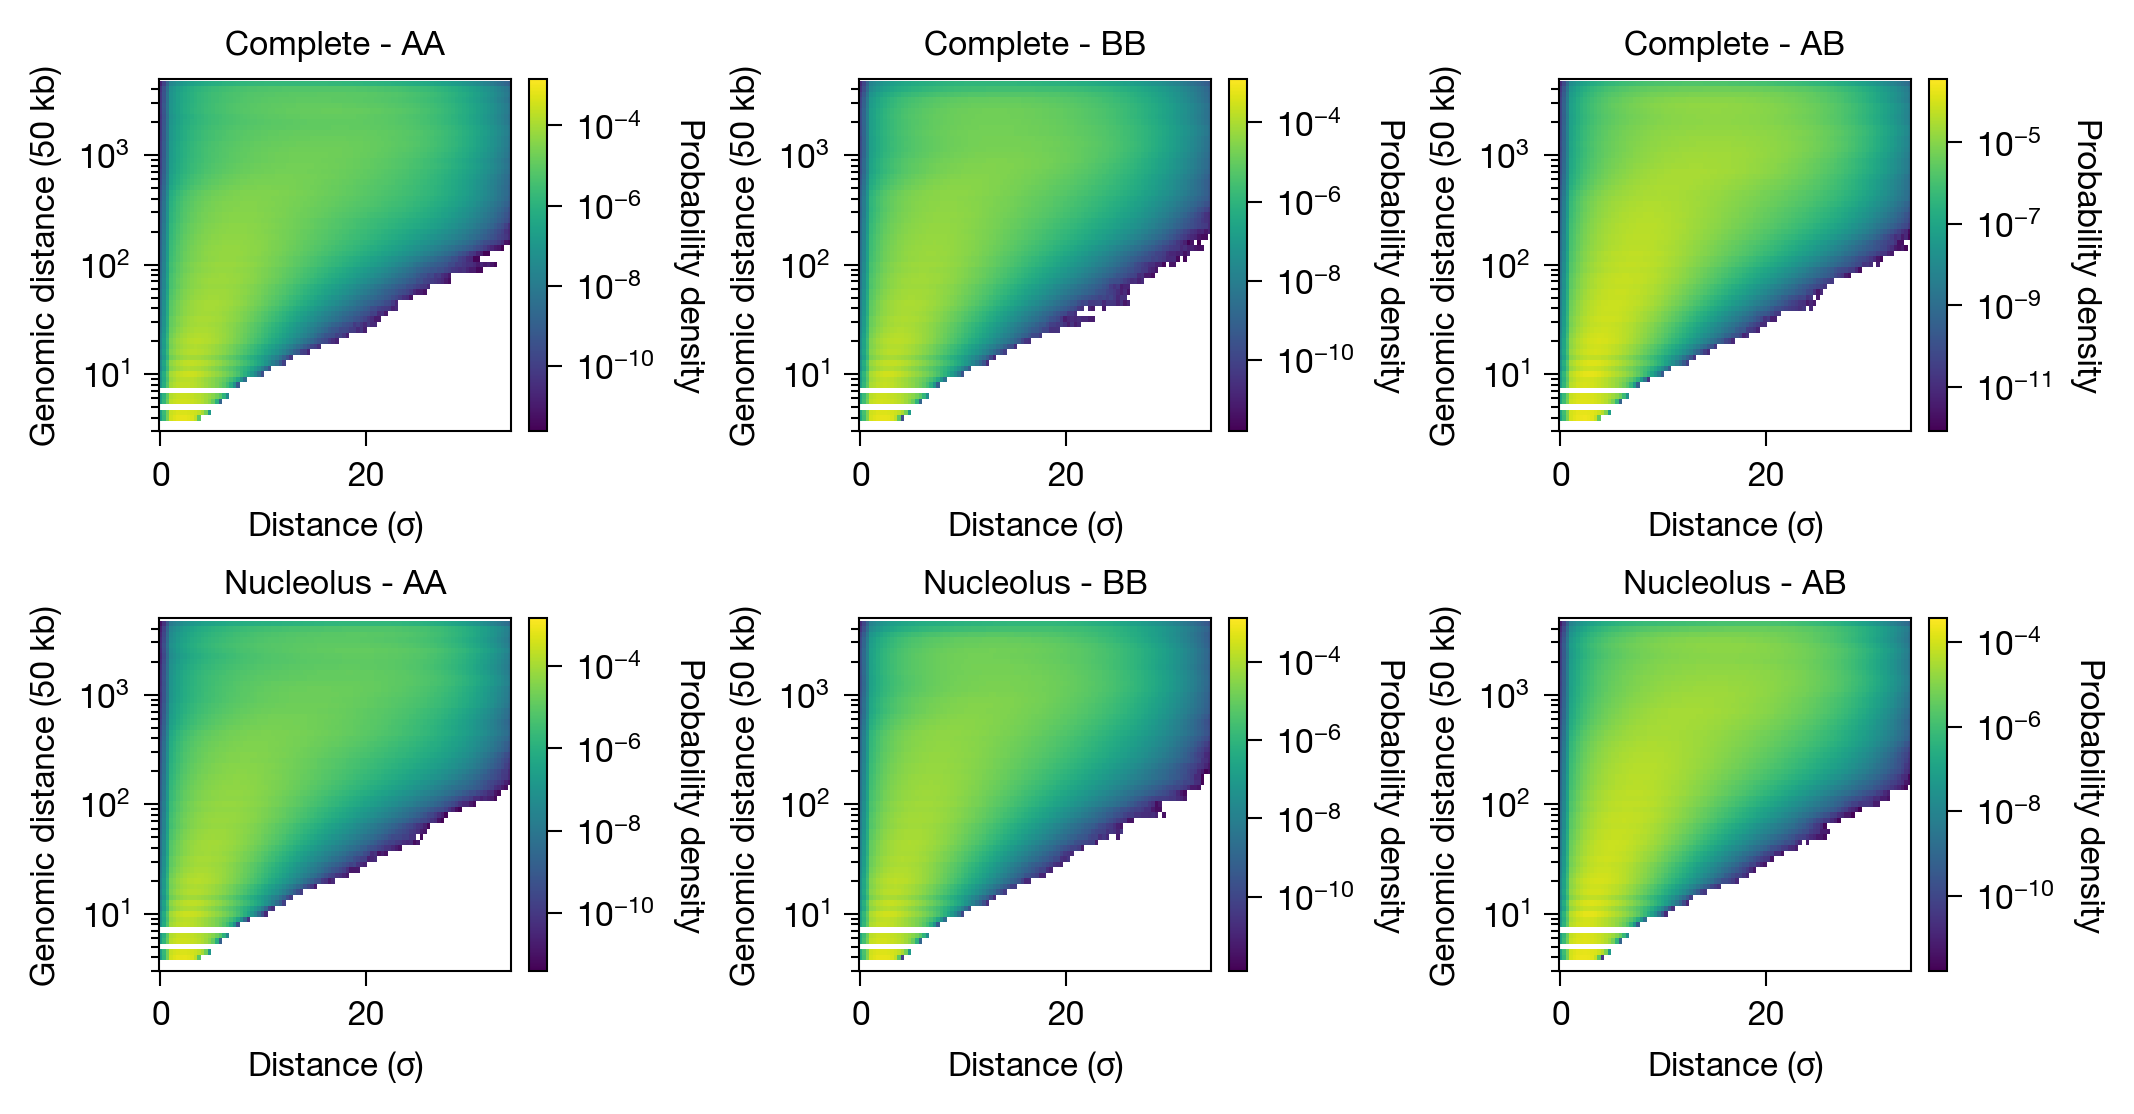

In [38]:
fig, ax = plt.subplots(2, 3, figsize=(7, 3.6), layout="constrained")

for i_idx, condition in enumerate(["complete", "nucleolus"]):
    for j_idx, label in enumerate(["AA", "BB", "AB"]):
        ratio = distance_histograms[condition][f"{label}"]
        xbins = distance_histograms[condition]["xbins"]
        ybins = distance_histograms[condition]["ybins"]

        # Create a meshgrid for plotting
        X, Y = np.meshgrid(xbins[:-1], ybins[:-1])

        # Plot the heatmap
        pcm = ax[i_idx, j_idx].pcolormesh(
            X,
            Y,
            ratio.T,
            shading="auto",
            cmap="viridis",
            norm=mpl.colors.LogNorm(
                vmin=ratio[ratio != 0].min(),
                vmax=ratio.max(),
            ),
        )
        ax[i_idx, j_idx].set_title(
            f"{condition.capitalize()} - {label}"
        )
        ax[i_idx, j_idx].set_yscale("log")
        ax[i_idx, j_idx].set_ylim([3, 4980])

        ax[i_idx, j_idx].set_xlabel(r"Distance ($\sigma$)")
        ax[i_idx, j_idx].set_ylabel("Genomic distance (50 kb)")

        cbar = fig.colorbar(pcm, ax=ax[i_idx, j_idx])
        cbar.set_label(
            "Probability density", rotation=270, labelpad=12
        )

/tmp/ipykernel_2507134/1630749743.py:14: RuntimeWarning: divide by zero encountered in divide
  distance_histograms["nucleolus"][f"{label}"]
/tmp/ipykernel_2507134/1630749743.py:14: RuntimeWarning: invalid value encountered in divide
  distance_histograms["nucleolus"][f"{label}"]


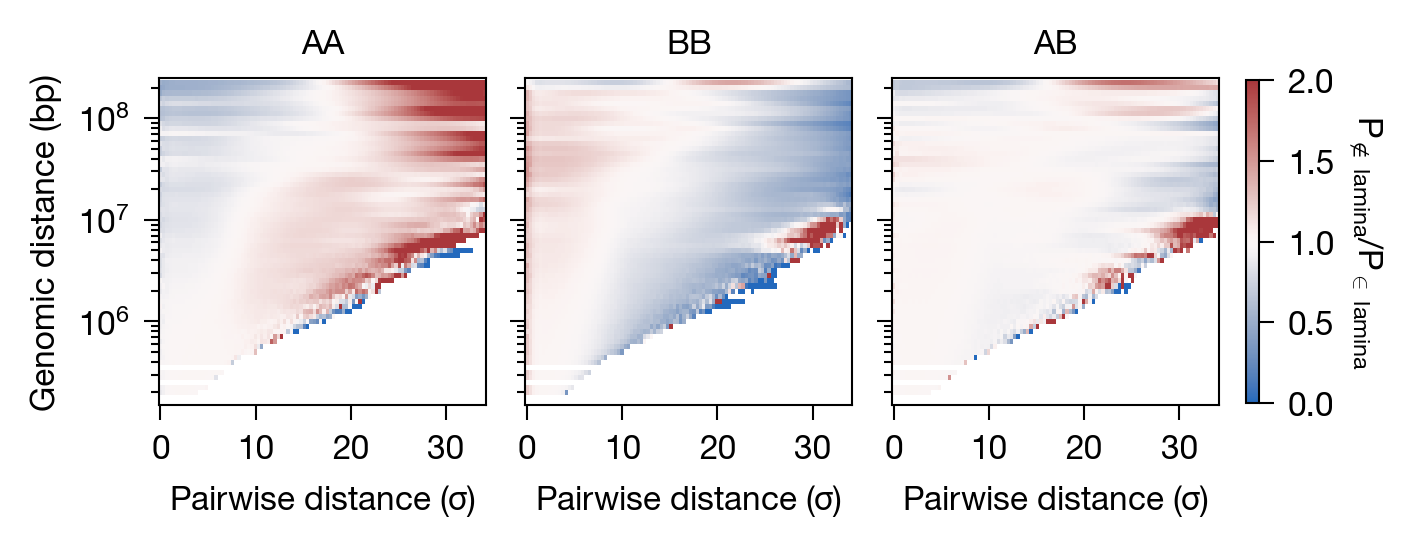

In [39]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(4.6, 1.8),
    layout="constrained",
    sharey=True,
    sharex=True,
)

custom_cmap = sns.color_palette("vlag", as_cmap=True)

for i_idx, label in enumerate(["AA", "BB", "AB"]):
    ratio = (
        distance_histograms["nucleolus"][f"{label}"]
        / distance_histograms["complete"][f"{label}"]
    )
    ratio[np.isnan(ratio)] = (
        np.nan
    )  # Set NaN values to zero for plotting
    ratio[ratio == np.inf] = (
        np.nan
    )  # Set infinite values to zero for plotting

    xbins = distance_histograms[condition]["xbins"]
    ybins = distance_histograms[condition]["ybins"] * 50e3

    # Create a meshgrid for plotting
    X, Y = np.meshgrid(xbins[:-1], ybins[:-1])

    # Plot the heatmap
    pcm = ax[i_idx].pcolormesh(
        X,
        Y,
        ratio.T,
        shading="auto",
        cmap=custom_cmap,
        vmax=2.0,
        vmin=0,
        edgecolors="face",  # Fills in the gaps between bins
        linewidth=0,  # Ensures no borders are drawn
        rasterized=True,  # Renders the heatmap as an image (faster, no white lines)
    )
    ax[i_idx].set_title(f"{label}")
    ax[i_idx].set_yscale("log")
    ax[i_idx].set_ylim([3 * 50e3, 4980 * 50e3])

    ax[i_idx].set_xlabel(r"Pairwise distance ($\sigma$)")

    ax[i_idx].set_xticks([0, 10, 20, 30])
    ax[i_idx].set_box_aspect(1)

# divider = make_axes_locatable(ax[-1])
# cax = divider.append_axes("right", size=0.05, pad=0.05)

# cbar = fig.colorbar(pcm, cax=cax, location="right")
ax[0].set_ylabel("Genomic distance (bp)")
# Pass the entire 'ax' array so space is taken equally from all plots
cbar = fig.colorbar(
    pcm, ax=ax, location="right", shrink=0.685, aspect=25, pad=0.025
)
cbar.set_label(
    r"$P_{\notin~\text{lamina}}/P_{\in~\text{lamina}}$",
    rotation=270,
    labelpad=12,
)

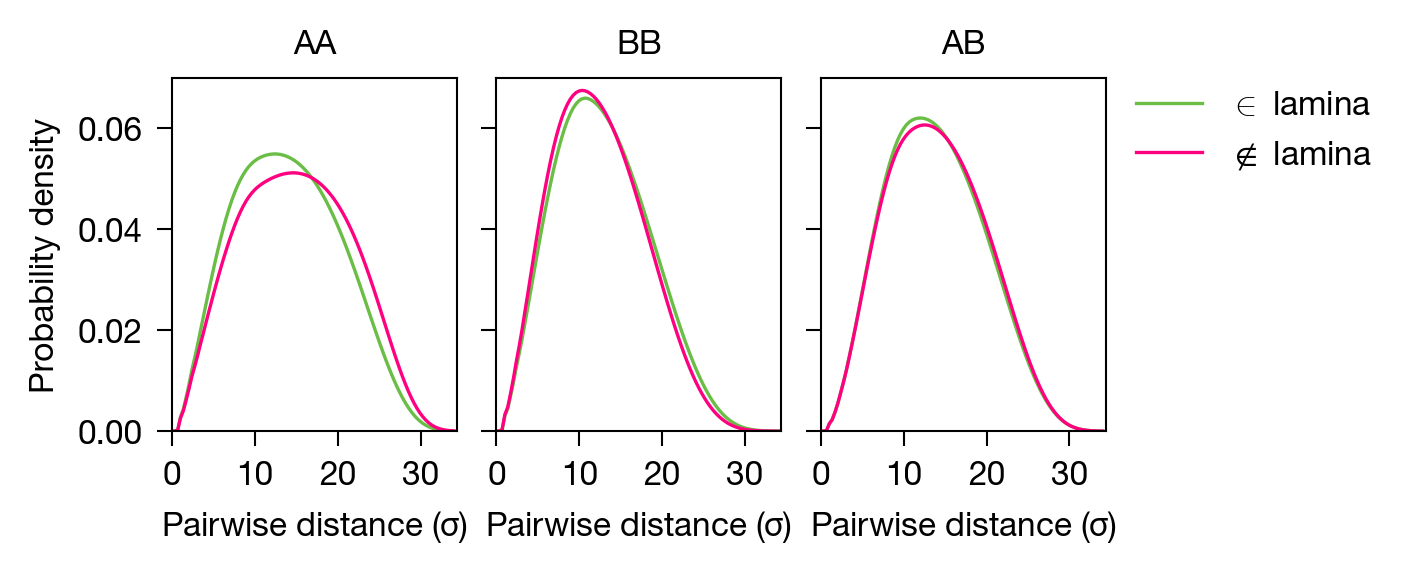

In [40]:
# plot the histogram of the distance for AA, BB, AB pairs for the complete and nucleolus conditions
# integrating over the genomic distance

fig, ax = plt.subplots(
    1,
    3,
    figsize=(4.6, 1.8),
    layout="constrained",
    sharex=True,
    sharey=True,
)
for i_idx, label in enumerate(["AA", "BB", "AB"]):
    ratio_complete = distance_histograms["complete"][f"{label}"]
    ratio_nucleolus = distance_histograms["nucleolus"][f"{label}"]

    xbins = distance_histograms["complete"]["xbins"]
    ybins = distance_histograms["complete"]["ybins"]

    dy = np.diff(ybins)

    # Integrate over the genomic distance (sum over the y-axis)
    integrated_complete = np.sum(ratio_complete * dy, axis=1)
    integrated_nucleolus = np.sum(ratio_nucleolus * dy, axis=1)

    # Plot the integrated histograms
    ax[i_idx].plot(
        xbins[:-1],
        integrated_complete,
        label=r"$\in~$lamina",
        color=color_palette["complete"],
    )
    ax[i_idx].plot(
        xbins[:-1],
        integrated_nucleolus,
        label=r"$\notin~$lamina",
        color=color_palette["nucleolus"],
    )
    ax[i_idx].set_title(f"{label}")
    ax[i_idx].set_xlabel(r"Pairwise distance ($\sigma$)")
    ax[i_idx].set_xticks([0, 10, 20, 30])
    ax[i_idx].set_xlim(xbins[0], xbins[-1])
    ax[i_idx].set_ylim(0, 0.07)
ax[0].set_ylabel("Probability density")
ax[-1].legend(
    frameon=False, loc="upper left", bbox_to_anchor=(1, 1.05)
)

# Concatenate distance matrices (only need to be done once)


In [5]:
distance_matrices = {}

for condition in conditions:
    distance_matrices[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        print(
            f"Processing condition: {condition}, replica: {replica}"
        )
        with h5py.File(
            os.path.join(
                OUTPUT_FOLDER,
                condition,
                f"distance-matrix-replica{replica}.h5",
            ),
            "r",
        ) as input_file:
            for key in input_file.keys():
                if key not in distance_matrices[condition]:
                    distance_matrices[condition][key] = input_file[
                        key
                    ][:]
                else:
                    distance_matrices[condition][key] += input_file[
                        key
                    ][:]

Processing condition: complete, replica: 1
Processing condition: complete, replica: 2
Processing condition: complete, replica: 3
Processing condition: complete, replica: 4
Processing condition: complete, replica: 5
Processing condition: complete, replica: 6
Processing condition: complete, replica: 7
Processing condition: complete, replica: 8
Processing condition: complete, replica: 9
Processing condition: complete, replica: 10
Processing condition: complete, replica: 11
Processing condition: complete, replica: 12
Processing condition: complete, replica: 13
Processing condition: complete, replica: 14
Processing condition: complete, replica: 15
Processing condition: complete, replica: 16
Processing condition: complete, replica: 17
Processing condition: complete, replica: 18
Processing condition: complete, replica: 19
Processing condition: complete, replica: 20
Processing condition: complete, replica: 21
Processing condition: complete, replica: 22
Processing condition: complete, replica: 

In [6]:
# convert to probability density distributions
for condition in conditions:
    distance_matrices[condition][
        "mean_distance_matrix"
    ] /= NUM_REPLICAS
    distance_matrices[condition][
        "mean_sq_distance_matrix"
    ] /= NUM_REPLICAS

    distance_matrices[condition]["std_distance_matrix"] = np.sqrt(
        NUM_REPLICAS
        / (NUM_REPLICAS - 1)
        * (
            distance_matrices[condition]["mean_sq_distance_matrix"]
            - distance_matrices[condition]["mean_distance_matrix"]
            ** 2
        )
    )

In [7]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "distance-matrix-aggregated.h5"),
    "w",
) as h5file:
    for condition in conditions:
        group = h5file.create_group(condition)
        for key, value in distance_matrices[condition].items():
            group.create_dataset(key, data=value)

# Plot distance matrices


In [41]:
distance_matrices = {}

with h5py.File(
    os.path.join(OUTPUT_FOLDER, "distance-matrix-aggregated.h5"),
    "r",
) as input_file:
    for condition in input_file.keys():
        distance_matrices[condition] = {}

        group = input_file[condition]
        for key in group.keys():
            distance_matrices[condition][key] = group[key][:]

In [42]:
annotations = np.loadtxt(
    "../../1_inputs/chr1_compartments.txt", dtype=object
)[:, 1]

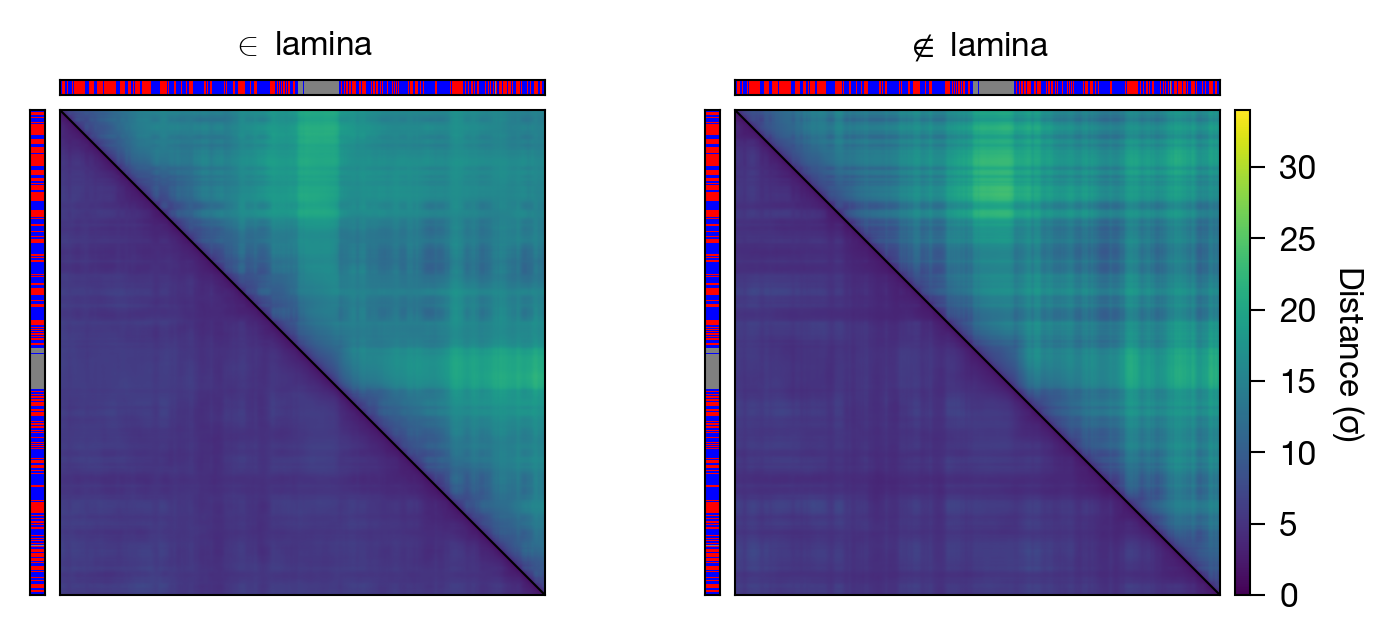

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(4.6, 1.8), layout="constrained")

# plot the mean distance matrix for the complete and nucleolus
# conditions in the upper diagonal and hte std distance matrix
# in the lower diagonal

title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

for i_idx, condition in enumerate(["complete", "nucleolus"]):
    plot_matrix = np.triu(
        distance_matrices[condition]["mean_distance_matrix"],
        k=1,
    ) + np.tril(
        distance_matrices[condition]["std_distance_matrix"],
        k=-1,
    )
    im = ax[i_idx].imshow(
        plot_matrix,
        cmap="viridis",
        vmin=0,
        vmax=34,
    )

    ax[i_idx].set_xticks([])
    ax[i_idx].set_yticks([])

    artist = plotting.PlotContactMap(fig=fig, ax=ax[i_idx])

    artist.add_compartment_annotations(
        annotations=annotations,
        colors="compartment",
        loc="left",
    )
    ax_top = artist.add_compartment_annotations(
        annotations=annotations,
        colors="compartment",
        loc="top",
    )

    xmin, xmax = ax[i_idx].get_xlim()
    ymin, ymax = ax[i_idx].get_ylim()

    ax[i_idx].plot(
        [xmin, xmax],
        [ymax, ymin],
        color="black",
        linestyle="-",
        linewidth=0.5,
    )

    ax_top.set_title(title[condition])

cbar = artist.add_colorbar(im)
cbar.set_label(r"Distance ($\sigma$)", rotation=270, labelpad=12)

/tmp/ipykernel_2507134/3597403942.py:12: RuntimeWarning: invalid value encountered in divide
  deviation_mean = (
/tmp/ipykernel_2507134/3597403942.py:17: RuntimeWarning: invalid value encountered in divide
  deviation_std = (


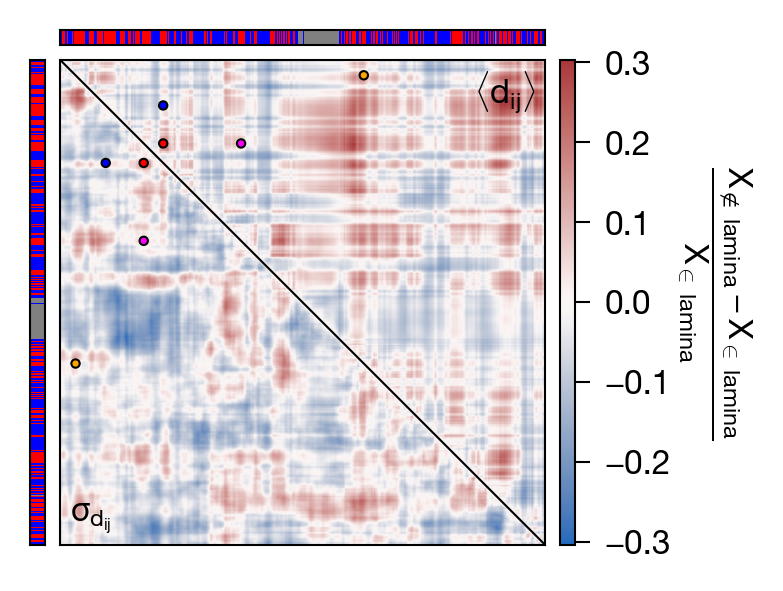

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8), layout="constrained")

# plot the mean distance matrix for the complete and nucleolus
# conditions in the upper diagonal and hte std distance matrix
# in the lower diagonal

title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

deviation_mean = (
    distance_matrices["nucleolus"]["mean_distance_matrix"]
    - distance_matrices["complete"]["mean_distance_matrix"]
) / distance_matrices["complete"]["mean_distance_matrix"]

deviation_std = (
    distance_matrices["nucleolus"]["std_distance_matrix"]
    - distance_matrices["complete"]["std_distance_matrix"]
) / distance_matrices["complete"]["std_distance_matrix"]

plot_matrix = np.triu(
    deviation_mean,
    k=1,
) + np.tril(
    deviation_std,
    k=-1,
)

custom_cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
custom_cmap = sns.color_palette("vlag", as_cmap=True)

clim = max(
    plot_matrix[np.isfinite(plot_matrix)].max(),
    -plot_matrix[np.isfinite(plot_matrix)].min(),
)

im = ax.imshow(
    plot_matrix,
    cmap=custom_cmap,
    vmin=-clim,
    vmax=clim,
)

ax.set_xticks([])
ax.set_yticks([])

artist = plotting.PlotContactMap(fig=fig, ax=ax)

artist.add_compartment_annotations(
    annotations=annotations,
    colors="compartment",
    loc="left",
)
ax_top = artist.add_compartment_annotations(
    annotations=annotations,
    colors="compartment",
    loc="top",
)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

ax.plot(
    [xmin, xmax],
    [ymax, ymin],
    color="black",
    linestyle="-",
    linewidth=0.5,
)

focused_pairs = [
    (159, 3119),
    (469, 1059),
    (859, 1059),
    (859, 1859),
]

color_pairs = [
    "orange",
    "blue",
    "red",
    "magenta",
]

ax.scatter(
    [i for i, _ in focused_pairs] + [j for _, j in focused_pairs],
    [j for _, j in focused_pairs] + [i for i, _ in focused_pairs],
    c=[i for i in color_pairs] + [j for j in color_pairs],
    s=4,
    edgecolors="black",
    linewidths=0.5,
)

ax.text(
    0.98,
    0.98,
    r"$\langle d_{ij} \rangle$",
    transform=ax.transAxes,
    fontsize=8,
    va="top",
    ha="right",
)
ax.text(
    0.02,
    0.02,
    r"$\sigma_{d_{ij}}$",
    transform=ax.transAxes,
    fontsize=8,
    va="bottom",
    ha="left",
)


cbar = artist.add_colorbar(im)
cbar.set_label(
    r"$\dfrac{X_{\notin~\text{lamina}}-X_{\in~\text{lamina}}}{X_{\in~\text{lamina}}}$",
    rotation=270,
    labelpad=20,
)

/tmp/ipykernel_2507134/1486041235.py:12: RuntimeWarning: invalid value encountered in divide
  deviation_mean = (
/tmp/ipykernel_2507134/1486041235.py:17: RuntimeWarning: invalid value encountered in divide
  deviation_std = (


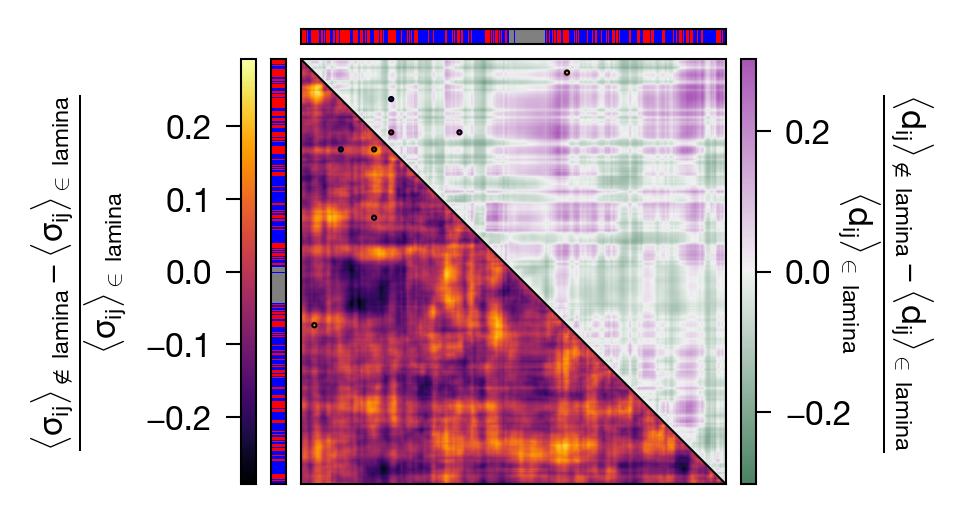

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(1.8, 1.8), layout="constrained")

# plot the mean distance matrix for the complete and nucleolus
# conditions in the upper diagonal and hte std distance matrix
# in the lower diagonal

title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

deviation_mean = (
    distance_matrices["nucleolus"]["mean_distance_matrix"]
    - distance_matrices["complete"]["mean_distance_matrix"]
) / distance_matrices["complete"]["mean_distance_matrix"]

deviation_std = (
    distance_matrices["nucleolus"]["std_distance_matrix"]
    - distance_matrices["complete"]["std_distance_matrix"]
) / distance_matrices["complete"]["std_distance_matrix"]

mask_for_mean = np.tril(
    np.ones_like(deviation_mean, dtype=bool), k=-1
)
mask_for_std = np.triu(np.ones_like(deviation_std, dtype=bool), k=1)

mean_masked = np.ma.masked_array(deviation_mean, mask=mask_for_mean)
std_masked = np.ma.masked_array(deviation_std, mask=mask_for_std)

custom_cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)

clim = max(
    mean_masked[np.isfinite(mean_masked)].max(),
    -mean_masked[np.isfinite(mean_masked)].min(),
)

im1 = ax.imshow(
    mean_masked,
    cmap=custom_cmap,
    vmin=-clim,
    vmax=clim,
)

clim = max(
    std_masked[np.isfinite(std_masked)].max(),
    -std_masked[np.isfinite(std_masked)].min(),
)

im2 = ax.imshow(
    std_masked,
    cmap="inferno",
    vmin=-clim,
    vmax=clim,
)

ax.set_xticks([])
ax.set_yticks([])

artist = plotting.PlotContactMap(fig=fig, ax=ax)

artist.add_compartment_annotations(
    annotations=annotations,
    colors="compartment",
    loc="left",
)
ax_top = artist.add_compartment_annotations(
    annotations=annotations,
    colors="compartment",
    loc="top",
)

cbar1 = artist.add_colorbar(im1, loc="right")
cbar1.set_label(
    r"$\dfrac{\langle d_{ij} \rangle_{\notin~\text{lamina}}-\langle d_{ij} \rangle_{\in~\text{lamina}}}{\langle d_{ij} \rangle_{\in~\text{lamina}}}$",
    rotation=270,
    labelpad=20,
)

cbar2 = artist.add_colorbar(im2, loc="left")
cbar2.set_label(
    r"$\dfrac{\langle \sigma_{ij} \rangle_{\notin~\text{lamina}}-\langle \sigma_{ij} \rangle_{\in~\text{lamina}}}{\langle \sigma_{ij} \rangle_{\in~\text{lamina}}}$",
)
cbar2.ax.yaxis.set_label_position("left")
cbar2.ax.yaxis.set_ticks_position("left")

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

ax.plot(
    [xmin, xmax],
    [ymax, ymin],
    color="black",
    linestyle="-",
    linewidth=0.5,
)

focused_pairs = [
    (159, 3119),
    (469, 1059),
    (859, 1059),
    (859, 1859),
]

color_pairs = [
    "orange",
    "blue",
    "red",
    "magenta",
]

ax.scatter(
    [i for i, _ in focused_pairs] + [j for _, j in focused_pairs],
    [j for _, j in focused_pairs] + [i for i, _ in focused_pairs],
    c=[i for i in color_pairs] + [j for j in color_pairs],
    s=1,
    edgecolors="black",
    linewidths=0.5,
)

# Concatenate focused distribution (only need to be done once)


In [41]:
distance_histograms = {}
focused_pairs = [
    (159, 3119),
    (469, 1059),
    (859, 1059),
    (859, 1859),
]
for i, j in focused_pairs:
    distance_histograms[f"{i}-{j}"] = {}
    for condition in conditions:
        distance_histograms[f"{i}-{j}"][condition] = {}

        for replica in range(1, NUM_REPLICAS + 1):
            print(
                f"Processing condition: {condition}, replica: {replica}"
            )
            with h5py.File(
                os.path.join(
                    OUTPUT_FOLDER,
                    condition,
                    f"pairwise-distance-histogram-replica{replica}-beads-{i}-{j}.h5",
                ),
                "r",
            ) as input_file:
                for key in input_file.keys():
                    if (
                        key
                        not in distance_histograms[f"{i}-{j}"][
                            condition
                        ]
                    ):
                        distance_histograms[f"{i}-{j}"][condition][
                            key
                        ] = input_file[key][:]
                    else:
                        if key not in ["bins"]:
                            distance_histograms[f"{i}-{j}"][
                                condition
                            ][key] += input_file[key][:]

Processing condition: complete, replica: 1
Processing condition: complete, replica: 2
Processing condition: complete, replica: 3
Processing condition: complete, replica: 4
Processing condition: complete, replica: 5
Processing condition: complete, replica: 6
Processing condition: complete, replica: 7
Processing condition: complete, replica: 8
Processing condition: complete, replica: 9
Processing condition: complete, replica: 10
Processing condition: complete, replica: 11
Processing condition: complete, replica: 12
Processing condition: complete, replica: 13
Processing condition: complete, replica: 14
Processing condition: complete, replica: 15
Processing condition: complete, replica: 16
Processing condition: complete, replica: 17
Processing condition: complete, replica: 18
Processing condition: complete, replica: 19
Processing condition: complete, replica: 20
Processing condition: complete, replica: 21
Processing condition: complete, replica: 22
Processing condition: complete, replica: 

In [42]:
# convert to probability density distributions
for i, j in focused_pairs:
    for condition in conditions:
        for key in distance_histograms[f"{i}-{j}"][condition].keys():
            if key not in ["bins"]:
                ratio = distance_histograms[f"{i}-{j}"][condition][
                    key
                ]
                bins = distance_histograms[f"{i}-{j}"][condition][
                    "bins"
                ]

                # Calculate bin widths
                bin_widths = np.diff(bins)

                # Normalize the histogram to get probability density
                total_count = np.sum(ratio)
                if total_count > 0:
                    distance_histograms[f"{i}-{j}"][condition][
                        key
                    ] = ratio / (total_count * bin_widths)

In [43]:
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        "pairwise-distance-histogram-focused-beads-aggregated.h5",
    ),
    "w",
) as h5file:
    for i, j in focused_pairs:
        group = h5file.create_group(f"{i}-{j}")
        for condition in conditions:
            subgroup = group.create_group(condition)
            for key, value in distance_histograms[f"{i}-{j}"][
                condition
            ].items():
                subgroup.create_dataset(key, data=value)

In [45]:
distance_histograms.keys()

dict_keys(['159-3119', '469-1059', '859-1059', '859-1859'])

# Plotting distribution


In [48]:
distance_histograms = {}
with h5py.File(
    os.path.join(
        OUTPUT_FOLDER,
        "pairwise-distance-histogram-focused-beads-aggregated.h5",
    ),
    "r",
) as h5file:
    for pair in h5file.keys():
        distance_histograms[pair] = {}

        for condition in h5file[pair].keys():
            distance_histograms[pair][condition] = {}

            for key in h5file[pair][condition].keys():
                distance_histograms[pair][condition][key] = h5file[
                    pair
                ][condition][key][:]

In [49]:
distance_histograms

{'159-3119': {'complete': {'bins': array([ 0.        ,  0.34357559,  0.68715118,  1.03072677,  1.37430236,
           1.71787795,  2.06145354,  2.40502913,  2.74860472,  3.09218031,
           3.4357559 ,  3.77933149,  4.12290708,  4.46648267,  4.81005826,
           5.15363385,  5.49720944,  5.84078503,  6.18436062,  6.52793621,
           6.8715118 ,  7.21508739,  7.55866298,  7.90223857,  8.24581416,
           8.58938975,  8.93296534,  9.27654093,  9.62011652,  9.96369211,
          10.3072677 , 10.65084329, 10.99441888, 11.33799447, 11.68157006,
          12.02514565, 12.36872124, 12.71229683, 13.05587242, 13.39944801,
          13.7430236 , 14.0865992 , 14.43017479, 14.77375038, 15.11732597,
          15.46090156, 15.80447715, 16.14805274, 16.49162833, 16.83520392,
          17.17877951, 17.5223551 , 17.86593069, 18.20950628, 18.55308187,
          18.89665746, 19.24023305, 19.58380864, 19.92738423, 20.27095982,
          20.61453541, 20.958111  , 21.30168659, 21.64526218, 21.988

In [50]:
(
    distance_histograms["159-3119"]["complete"]["counts"]
    - distance_histograms["469-1059"]["complete"]["counts"]
)

array([ 0.00000000e+00,  0.00000000e+00, -1.81890581e-05, -7.36717910e-04,
       -1.17329555e-03, -1.80995488e-03, -3.24704090e-03, -4.86601750e-03,
       -6.07568810e-03, -7.45815986e-03, -9.16806129e-03, -1.14419190e-02,
       -1.31336225e-02, -1.45615765e-02, -1.74811731e-02, -1.73446698e-02,
       -1.96458183e-02, -1.93455641e-02, -2.32748196e-02, -2.29290733e-02,
       -2.38567869e-02, -2.60396700e-02, -2.61305467e-02, -2.81224375e-02,
       -2.79041091e-02, -2.85953080e-02, -2.96503805e-02, -2.92501168e-02,
       -3.12692988e-02, -2.98958461e-02, -3.11874214e-02, -2.98685186e-02,
       -3.13328813e-02, -3.18604227e-02, -3.21969701e-02, -2.87041316e-02,
       -2.75581074e-02, -2.63938235e-02, -2.40743921e-02, -2.39743110e-02,
       -1.86533000e-02, -1.90808234e-02, -1.63338977e-02, -1.54061558e-02,
       -8.72989481e-03, -9.22101098e-03, -2.91770076e-03,  2.00312813e-03,
        3.86771363e-03,  7.54235806e-03,  1.10260344e-02,  1.21994064e-02,
        1.63652447e-02,  

Text(0.02, 0.577, 'Probability density')

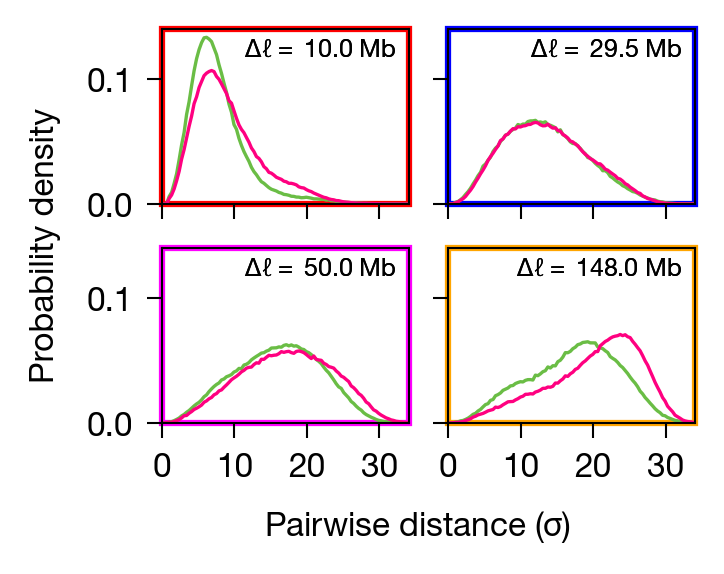

In [54]:
fig, ax = plt.subplots(
    2,
    2,
    figsize=(2.3, 1.8),
    layout="constrained",
    sharex=True,
    sharey=True,
)

focused_pairs = [
    (859, 1059),
    (469, 1059),
    (859, 1859),
    (159, 3119),
]

border_colors = [
    "red",
    "blue",
    "magenta",
    "orange",
]

ax = ax.flatten()
for idx, (i, j) in enumerate(focused_pairs):
    for condition in ["complete", "nucleolus"]:
        x = distance_histograms[f"{i}-{j}"][condition]["bins"][:-1]
        ax[idx].plot(
            x,
            distance_histograms[f"{i}-{j}"][condition]["counts"],
            label=title[condition],
            color=color_palette[condition],
        )
        # ax[idx].set_title(f"Beads {i+1}-{j+1}")

        # set aspect to square
        # ax[idx].set_box_aspect(1)
        ax[idx].patch.set_linewidth(1.5)
        ax[idx].patch.set_edgecolor(border_colors[idx])
        ax[idx].set_xlim(x[0], x[-1])
        ax[idx].set_ylim(0, 0.14)
        ax[idx].set_xticks([0, 10, 20, 30])
        ax[idx].text(
            0.95,
            0.95,
            rf"$\Delta \ell =$ {(np.abs(i-j))*50e3/1e6:.1f} Mb",
            transform=ax[idx].transAxes,
            fontsize=6,
            va="top",
            ha="right",
        )

fig.supxlabel(r"Pairwise distance ($\sigma$)", x=0.58, fontsize=8)
fig.supylabel(r"Probability density", y=0.577, fontsize=8)

In [50]:
ax

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)